In [1]:
from config_feature import FEATURES, LABEL
import pandas as pd
from sklearn.preprocessing import StandardScaler


# Trainings- und Testdaten laden
train_df = pd.read_parquet('train_block_1.parquet')
test_df = pd.read_parquet('test_block_1.parquet')

#train_df.to_csv("train.csv", index=False)
#train_df.head()

In [2]:
# Label umwandeln: 'attack' → 1, 'benign' → 0
train_df[LABEL] = train_df[LABEL].map({'attack': 1, 'benign': 0})
test_df[LABEL] = test_df[LABEL].map({'attack': 1, 'benign': 0})

# Features und Label auswählen
X_train = train_df[FEATURES]
y_train = train_df[LABEL]
X_test = test_df[FEATURES]
y_test = test_df[LABEL]

# Features skalieren (Scaler auf Trainingsdaten fitten, auf beide anwenden)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
test_df.head()

,timestamp,ase_spec,br_immed_spec,br_indirect_spec,br_mis_pred,br_pred,br_return_spec,branch-load-misses,branch-loads,branch-misses,...,writeback_writeback_single_inode,writeback_writeback_single_inode_start,writeback_writeback_start,writeback_writeback_wait,writeback_writeback_wait_iff_congested,writeback_writeback_wake_background,writeback_writeback_write_inode,writeback_writeback_written,attack,Label
0,2025-07-22T19:53:10,847.0,540525.0,115706.0,15452.0,656131.0,96680.0,15185.0,651088.0,14893.0,...,549617,549617,1336098,0,0,210,472963,1336098,benign,0
1,2025-07-22T19:53:20,808.0,527069.0,112884.0,14933.0,639855.0,94312.0,14941.0,640294.0,14456.0,...,549628,549628,1336113,0,0,210,472972,1336113,benign,0
2,2025-07-22T19:53:30,844.0,537613.0,115032.0,15021.0,652547.0,96070.0,14841.0,642126.0,15904.0,...,549640,549640,1336127,0,0,210,472982,1336127,benign,0
3,2025-07-22T19:53:40,879.0,530950.0,113144.0,14686.0,643996.0,94525.0,14882.0,640138.0,15161.0,...,549650,549650,1336139,0,0,210,472991,1336139,benign,0
4,2025-07-22T19:53:50,872.0,533494.0,113819.0,14967.0,647215.0,95060.0,14997.0,650649.0,14580.0,...,549654,549654,1336149,0,0,210,472995,1336149,benign,0


In [4]:
import numpy as np

def create_sequences(X, y, window_size=10):
    X_seq = []
    y_seq = []
    for i in range(len(X) - window_size + 1):
        label_window = y[i:i+window_size]
        # Prüfen, ob alle Labels gleich sind (entweder alles 0 oder alles 1)
        if np.all(label_window == label_window[0]):
            X_seq.append(X[i:i+window_size])
            y_seq.append(label_window[0])
    return np.array(X_seq), np.array(y_seq)


In [5]:
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, window_size=10)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, window_size=10)

print(X_train_seq.shape)  # (Anzahl Fenster, 10, Anzahl Features)
print(y_train_seq.shape)  # (Anzahl Fenster,)


(4586, 10, 20)
(4586,)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def create_lstm_model(num_features):
    model = Sequential([
        LSTM(30, input_shape=(10, num_features), return_sequences=True),
        Dropout(0.2),
        LSTM(15),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model = create_lstm_model(len(FEATURES))
model.summary()

print(len(FEATURES))


2025-07-26 13:41:06.148052: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-26 13:41:06.148673: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-26 13:41:06.151062: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-26 13:41:06.156718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753530066.168473  138934 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753530066.17

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 30)         │         6,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15)             │         2,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,896 (34.75 KB)

 Trainable params: 8,896 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

20


In [7]:
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9199 - loss: 0.3252 - val_accuracy: 0.9015 - val_loss: 0.2791
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9769 - loss: 0.0960 - val_accuracy: 0.9015 - val_loss: 0.2750
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9797 - loss: 0.0761 - val_accuracy: 0.9051 - val_loss: 0.3365
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9813 - loss: 0.0587 - val_accuracy: 0.9124 - val_loss: 0.3708
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9779 - loss: 0.0490 - val_accuracy: 0.9093 - val_loss: 0.4293
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9850 - loss: 0.0404 - val_accuracy: 0.9067 - val_loss: 0.4836
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9932 - loss: 0.0262 - val_accuracy: 0.9077 - val_loss: 0.4770
Epoch 8/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9913 - loss: 0.0284 - val_accuracy: 0.

In [8]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Vorhersage für Sequenzdaten
y_pred_prob = model.predict(X_test_seq)

# 2. Wahrscheinlichkeiten zu Klassenlabels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Genauigkeit und Klassifikationsbericht (jetzt gleiche Länge!)
accuracy = accuracy_score(y_test_seq, y_pred)
report = classification_report(y_test_seq, y_pred)

# 4. Ausgabe
print(f"Genauigkeit: {accuracy:.4f}")
print(report)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Genauigkeit: 0.9062
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1676
           1       0.99      0.29      0.45       253

    accuracy                           0.91      1929
   macro avg       0.94      0.64      0.70      1929
weighted avg       0.91      0.91      0.88      1929



61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1675    1]
 [ 180   73]]


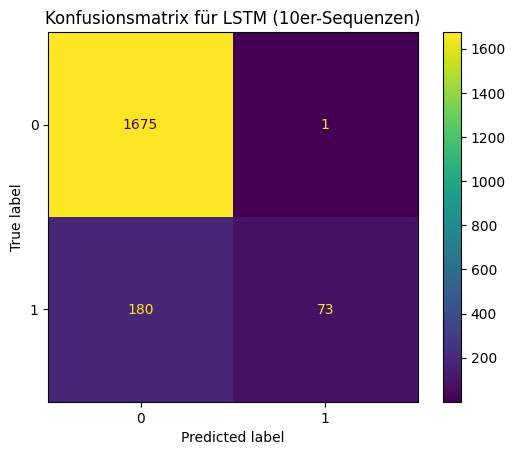

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Vorhersagen für die Testdaten erstellen – ACHTUNG: _seq benutzen!
y_pred_seq = (model.predict(X_test_seq) > 0.5).astype(int).flatten()

# 2. Konfusionsmatrix berechnen – die Längen passen jetzt!
cm = confusion_matrix(y_test_seq, y_pred_seq)

# 3. Konfusionsmatrix als Zahlen ausgeben
print(cm)

# 4. Konfusionsmatrix als Grafik anzeigen
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Konfusionsmatrix für LSTM (10er-Sequenzen)')
plt.show()


In [10]:
# Annahme: Du hast bereits diese Arrays für die Sequenzdaten:
# X_test_seq (Form: [Anzahl_Fenster, 10, n_features])
# y_test_seq (Form: [Anzahl_Fenster,])
# y_pred_seq (Form: [Anzahl_Fenster,])

# Damit der Angriffstyp zum Fenster passt:
# Nimm für jedes Fenster das Label der ERSTEN Zeile
window_size = 10

attack_seq = []
attack_array = test_df["attack"].values
for i in range(len(attack_array) - window_size + 1):
    window_labels = y_test.values[i:i+window_size]
    # Fenster nur aufnehmen, wenn alle Labels gleich (wie vorher schon beim Sequenzbau!)
    if np.all(window_labels == window_labels[0]):
        # Greife den Angriffstyp der ersten Zeile im Fenster
        attack_seq.append(attack_array[i])

attack_seq = np.array(attack_seq)  # jetzt genauso lang wie y_test_seq und y_pred_seq

# DataFrame bauen
df = pd.DataFrame({
    "y_true": y_test_seq,
    "y_pred": y_pred_seq,
    "attack": attack_seq
})

# Falsch klassifizierte Angriffe filtern (echte Angriffe als benign erkannt)
mask = (df["y_true"] == 1) & (df["y_pred"] == 0)
falsch_klassifizierte = df[mask]
print(falsch_klassifizierte["attack"].value_counts())


attack
osfingerprinting    51
aggressivescan      51
portscan            41
slowloris           37
Name: count, dtype: int64


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


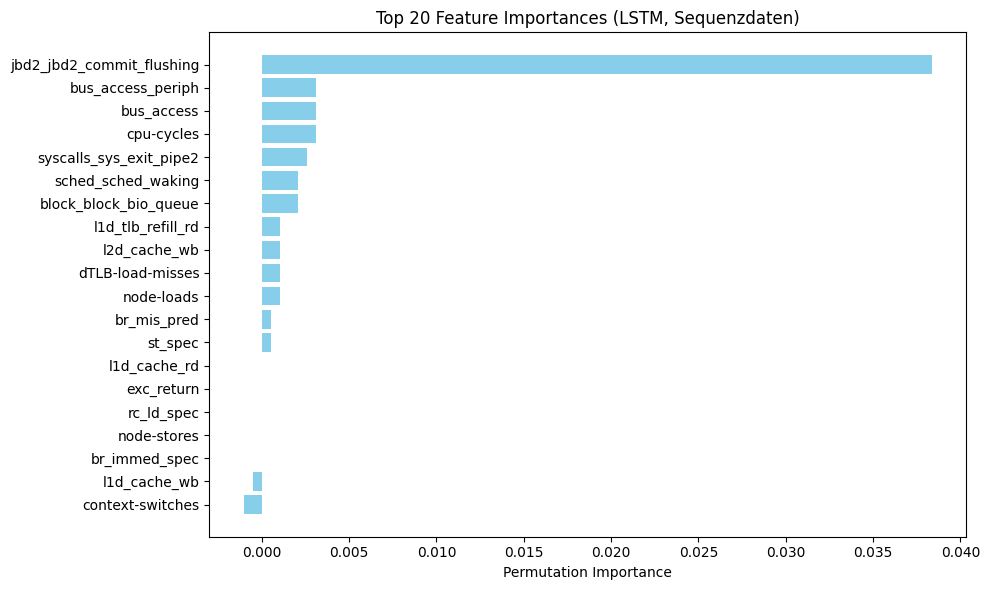

In [11]:
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Annahme: model, X_test_seq, y_test_seq, FEATURES sind bereits definiert

# 1. Baseline-Genauigkeit für das sequenzierte Testset
y_pred_seq = model.predict(X_test_seq)
original_acc = accuracy_score(y_test_seq, (y_pred_seq > 0.5).astype(int))

feature_importances = []
for i in range(X_test_seq.shape[2]):
    X_test_perm = X_test_seq.copy()
    # Shuffle das i-te Feature über alle Fenster und Zeitschritte
    np.random.shuffle(X_test_perm[:, :, i])
    y_pred_perm = model.predict(X_test_perm)
    perm_acc = accuracy_score(y_test_seq, (y_pred_perm > 0.5).astype(int))
    feature_importances.append(original_acc - perm_acc)

# 2. Top 20 Features finden
indices_top20 = np.argsort(feature_importances)[-20:][::-1]
top20_features = [FEATURES[i] for i in indices_top20]
top20_importances = [feature_importances[i] for i in indices_top20]

# 3. Balkendiagramm zeichnen
plt.figure(figsize=(10, 6))
plt.barh(top20_features[::-1], top20_importances[::-1], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Top 20 Feature Importances (LSTM, Sequenzdaten)')
plt.tight_layout()
plt.show()


In [13]:
print(top20_features)


['cache-references', 'cache-misses', 'bus-cycles', 'cpu_cycles', 'instructions', 'branch-misses', 'cpu-cycles', 'l2d_cache_refill', 'bus_access_not_shared', 'context-switches', 'bus_access_rd', 'bus_cycles', 'bus_access', 'l2d_cache_refill_rd', 'node-stores', 'bus_access_normal', 'syscalls_sys_enter_clock_gettime', 'syscalls_sys_enter_epoll_pwait2', 'syscalls_sys_enter_execve', 'syscalls_sys_enter_epoll_ctl']


In [12]:
from tensorflow.keras.models import load_model
import joblib

model.save('lstm_model_20events.h5')
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [13]:
print(scaler.feature_names_in_)


['node-stores' 'cpu-cycles' 'block_block_bio_queue'
 'jbd2_jbd2_commit_flushing' 'syscalls_sys_exit_pipe2' 'st_spec'
 'dTLB-load-misses' 'sched_sched_waking' 'bus_access' 'br_immed_spec'
 'bus_access_periph' 'l1d_cache_rd' 'l1d_cache_wb' 'node-loads'
 'l2d_cache_wb' 'l1d_tlb_refill_rd' 'context-switches' 'rc_ld_spec'
 'exc_return' 'br_mis_pred']
